<a href="https://colab.research.google.com/github/nurulfdlharba-dotcom/rf-dataset-sekunder/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset1.csv to dataset1 (1).csv


# 1. Import library

In [ ]:
# Pengolahan data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Evaluasi model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# 2. Load dataset

In [ ]:
# Membaca dataset CSV
df = pd.read_csv('/content/dataset1.csv')

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan jumlah baris dan kolom
print("Ukuran dataset:", df.shape)

# Menampilkan nama-nama kolom
print("Nama kolom:", df.columns.tolist())

     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  Output
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11       0
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29       0
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03       0
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82       0
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26       1
Ukuran dataset: (880, 13)
Nama kolom: ['N', 'P', 'K', 'pH', 'EC', 'OC', 'S', 'Zn', 'Fe', 'Cu', 'Mn', 'B', 'Output']


# 3. Cleaning dataset

In [10]:
# Mengecek kondisi dataset sebelum cleaning
print("=== KONDISI DATASET SEBELUM CLEANING ===")

# Menampilkan informasi dataset
print("\nInformasi Dataset:")
print(df.info())

# Mengecek missing value
print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

=== KONDISI DATASET SEBELUM CLEANING ===

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   N       880 non-null    int64  
 1   P       880 non-null    float64
 2   K       880 non-null    int64  
 3   pH      880 non-null    float64
 4   EC      880 non-null    float64
 5   OC      880 non-null    float64
 6   S       880 non-null    float64
 7   Zn      880 non-null    float64
 8   Fe      880 non-null    float64
 9   Cu      880 non-null    float64
 10  Mn      880 non-null    float64
 11  B       880 non-null    float64
 12  Output  880 non-null    int64  
dtypes: float64(10), int64(3)
memory usage: 89.5 KB
None

Jumlah Missing Value:
N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Jumlah Data Duplikat:
0


In [11]:
# Menghapus data duplikat
df = df.drop_duplicates()

# Menghapus data yang memiliki missing value
df = df.dropna()

# Mengatur ulang index
df = df.reset_index(drop=True)

In [13]:
# Mengecek kondisi dataset setelah cleaning
print("=== KONDISI DATASET SETELAH CLEANING ===")

# Menampilkan ukuran dataset
print("\nUkuran Dataset:")
print(df.shape)

# Mengecek missing value
print("\nJumlah Missing Value:")
print(df.isnull().sum())

# Mengecek data duplikat
print("\nJumlah Data Duplikat:")
print(df.duplicated().sum())

# Menampilkan 5 data pertama
print("\n5 Data Pertama:")
print(df.head())

=== KONDISI DATASET SETELAH CLEANING ===

Ukuran Dataset:
(880, 13)

Jumlah Missing Value:
N         0
P         0
K         0
pH        0
EC        0
OC        0
S         0
Zn        0
Fe        0
Cu        0
Mn        0
B         0
Output    0
dtype: int64

Jumlah Data Duplikat:
0

5 Data Pertama:
     N    P    K    pH    EC    OC     S    Zn    Fe    Cu    Mn     B  Output
0  138  8.6  560  7.46  0.62  0.70   5.9  0.24  0.31  0.77  8.71  0.11       0
1  213  7.5  338  7.62  0.75  1.06  25.4  0.30  0.86  1.54  2.89  2.29       0
2  163  9.6  718  7.59  0.51  1.11  14.3  0.30  0.86  1.57  2.70  2.03       0
3  157  6.8  475  7.64  0.58  0.94  26.0  0.34  0.54  1.53  2.65  1.82       0
4  270  9.9  444  7.63  0.40  0.86  11.8  0.25  0.76  1.69  2.43  2.26       1


# 4. EDA

In [14]:
# Statistik deskriptif dataset
print("=== STATISTIK DESKRIPTIF ===")
print(df[['N', 'P', 'K', 'pH', 'EC']].describe())

=== STATISTIK DESKRIPTIF ===
               N           P           K          pH          EC
count  880.00000  880.000000  880.000000  880.000000  880.000000
mean   246.73750   14.562159  499.978409    7.510500    0.543659
std     77.38886   21.967755  124.222838    0.464912    0.141597
min      6.00000    2.900000   11.000000    0.900000    0.100000
25%    201.00000    6.800000  412.000000    7.350000    0.430000
50%    257.00000    8.100000  475.000000    7.500000    0.545000
75%    307.00000   10.550000  581.000000    7.630000    0.640000
max    383.00000  125.000000  887.000000   11.150000    0.950000


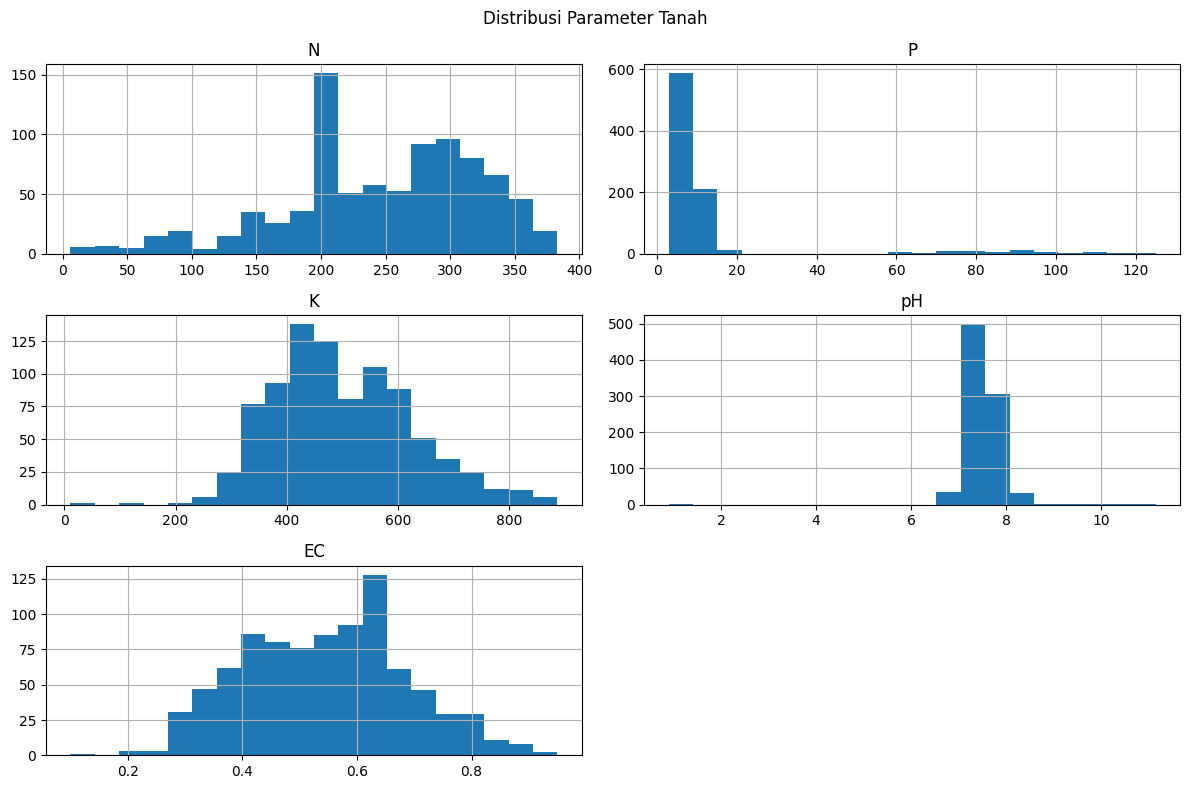

In [15]:
# Visualisasi distribusi data
df[['N', 'P', 'K', 'pH', 'EC']].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle('Distribusi Parameter Tanah')
plt.tight_layout()
plt.show()

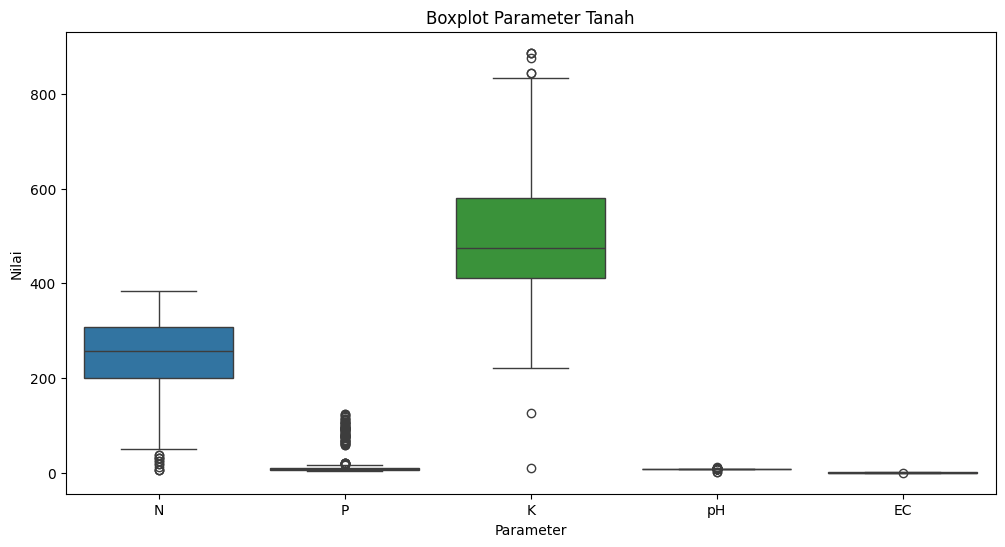

In [16]:
# Boxplot untuk melihat outlier
plt.figure(figsize=(12, 6))

sns.boxplot(data=df[['N', 'P', 'K', 'pH', 'EC']])

plt.title('Boxplot Parameter Tanah')
plt.xlabel('Parameter')
plt.ylabel('Nilai')
plt.show()

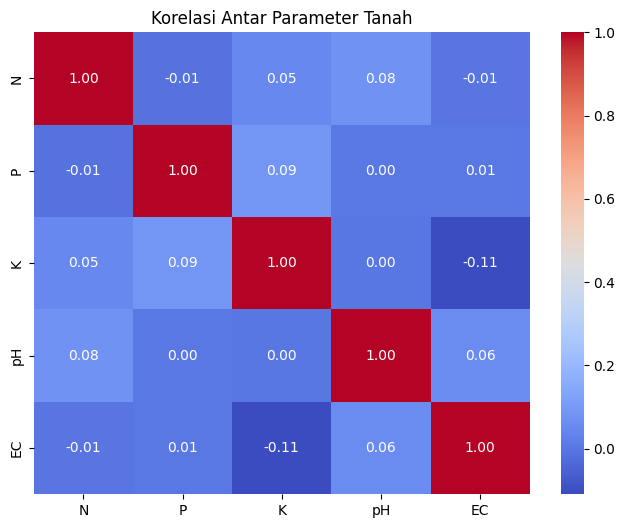

In [17]:
# Melihat korelasi antar parameter
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[['N', 'P', 'K', 'pH', 'EC']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Korelasi Antar Parameter Tanah')
plt.show()